# 🎵 Playlist Sorter
Laadt een `combined.csv` bestand en sorteert songs in **Calm**, **Energy** en **Other** op basis van instelbare parameters.

---

## 1. Imports & Bestand laden

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

from pathlib import Path



In [2]:
os.getcwd()


'c:\\Users\\astri\\Desktop\\Data_Scientist\\Eindwerk\\spotify-project\\docs\\playgrounds\\av_playground\\music_class_ml'

In [59]:
# ══════════════════════════════════════════════════════════════════════════════
#  PADEN
# ══════════════════════════════════════════════════════════════════════════════
PARTICIPANT = "courgette"                                    # codename van de deelnemer
INPUT_DIR   = Path(f"../../../../data/playlists/{PARTICIPANT}/losse_csv")        # map met Exportify CSV's
OUTPUT_DIR  = Path(f"../../../../data/playlists/{PARTICIPANT}/playlists_generated")            # output map

# ══════════════════════════════════════════════════════════════════════════════
#  PREPARE – filters voor ongeschikte songs
# ══════════════════════════════════════════════════════════════════════════════
MAX_SPEECHINESS = 0.70   # > deze waarde = te veel gesproken woord
MAX_LIVENESS    = 0.80   # > deze waarde = live-opname met publiek


In [60]:
# ══════════════════════════════════════════════════════════════════════════════
#  PREPARE: CSV's inladen & opschonen
# ══════════════════════════════════════════════════════════════════════════════


COLUMN_MAPPING = {
    'Track Name'       : 'name',
    'Artist Name(s)'   : 'artists',
    'Album Name'       : 'album',
    'Duration (ms)'    : 'duration_ms',
    'Tempo'            : 'tempo',
    'Energy'           : 'energy',
    'Valence'          : 'valence',
    'Acousticness'     : 'acousticness',
    'Danceability'     : 'danceability',
    'Loudness'         : 'loudness',
    'Speechiness'      : 'speechiness',
    'Instrumentalness' : 'instrumentalness',
    'Liveness'         : 'liveness',
    'Key'              : 'key',
    'Mode'             : 'mode',
    'Time Signature'   : 'time_signature',
    'Track URI'        : 'uri',
}

# Stap 1: CSV bestanden vinden
csv_files = sorted(INPUT_DIR.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"Geen CSV bestanden gevonden in: {INPUT_DIR}")
print(f"Gevonden: {len(csv_files)} CSV bestand(en)")
for f in csv_files:
    print(f"  - {f.name}")

# Stap 2: Inladen & combineren
frames = []
for f in csv_files:
    try:
        frames.append(pd.read_csv(f))
    except Exception as e:
        print(f"  Kon {f.name} niet lezen: {e}")
df = pd.concat(frames, ignore_index=True)
print(f"\nTotaal ingeladen: {len(df)} rijen")

# Stap 3: Kolommen hernoemen
df = df.rename(columns={k: v for k, v in COLUMN_MAPPING.items() if k in df.columns})

# Stap 4: Duplicaten verwijderen op basis van Track URI
before = len(df)
if 'uri' in df.columns:
    df = df.drop_duplicates(subset=['uri'], keep='first')
    removed = before - len(df)
    if removed:
        print(f"Duplicaten verwijderd: {removed}")

# Stap 5: Ongeschikte songs filteren
before = len(df)
if 'speechiness' in df.columns:
    df = df[df['speechiness'] <= MAX_SPEECHINESS]
if 'liveness' in df.columns:
    df = df[df['liveness'] <= MAX_LIVENESS]
removed = before - len(df)
if removed:
    print(f"Ongeschikt gefilterd: {removed} (speechiness / liveness)")

# Stap 6: combined.csv opslaan
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_DIR / 'combined.csv', index=False)

print(f"\nKlaar: {len(df)} unieke songs")
print(f"Opgeslagen: {OUTPUT_DIR / 'combined.csv'}")
df.head(3)

Gevonden: 35 CSV bestand(en)
  - 2000s_Emo_Mix.csv
  - 90's_Workout.csv
  - 90s_Dance_Party.csv
  - 90s_Party.csv
  - African_Tribal_Orchestra_Mix.csv
  - All_Out_2000s.csv
  - Best_of_'00s_Pop.csv
  - Calm_Down.csv
  - Calming_Classical.csv
  - Chill-mix.csv
  - Chilled_Classical_Covers.csv
  - Classic_Road_Trip_Songs.csv
  - Contemporary_Folk.csv
  - Creative_Focus.csv
  - Dancefloor_Classics.csv
  - Easy_Rock.csv
  - Energy_Booster_Pop.csv
  - Energy_Booster_Rock.csv
  - Feel_Good_Classics.csv
  - Folk_Feast.csv
  - Heavy_Workout.csv
  - Iconic_Soundtracks.csv
  - Indie_Folk_Coffee_&_Cedar.csv
  - Irish_Folk.csv
  - Klara_Top_100.csv
  - Mood_Booster.csv
  - Morning_Coffee.csv
  - Relax_&_Unwind.csv
  - Soft_Instrumental.csv
  - Songs_to_Sing_in_the_Shower.csv
  - This_is_Amyl_and_The_Sniffers.csv
  - This_is_GOOSE.csv
  - Top_Hits_Workout.csv
  - Van_Life.csv
  - Workout_Beats.csv

Totaal ingeladen: 3437 rijen
Duplicaten verwijderd: 333
Ongeschikt gefilterd: 15 (speechiness / liven

C:\Users\astri\AppData\Local\Temp\ipykernel_21652\4060050065.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(frames, ignore_index=True)


,uri,name,album,artists,Release Date,duration_ms,Popularity,Explicit,Added By,Added At,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,spotify:track:1wZ7o1mZysv1l26ZWawVfW,Freedom! '90 - Remastered,Listen Without Prejudice Vol. 1 (Remastered),George Michael,1990-09-01,390861,69,False,NaN,2024-07-12T19:59:45Z,...,5,-10.352,1,0.0451,0.2430,0.000032,0.0601,0.938,91.703,4
1,spotify:track:7aQjPecQdIuNd1sz3KCDhD,Lovefool,First Band On The Moon (Remastered),The Cardigans,1996-01-01,193953,84,False,NaN,2024-07-12T19:59:45Z,...,9,-6.029,1,0.0252,0.0344,0.000000,0.3500,0.890,111.845,4
2,spotify:track:6MdqqkQ8sSC0WB4i8PyRuQ,No Diggity,Another Level,Blackstreet;Dr. Dre;Queen Pen,1996-09-09,304600,79,False,NaN,2024-07-12T19:59:45Z,...,1,-4.674,0,0.2880,0.3030,0.000000,0.2790,0.670,88.634,4


In [61]:
# ── Pad naar je combined.csv ──────────────────────────────────────────────────
CSV_PATH = "../../../../data/playlists/courgette/playlists_generated/combined.csv"   # <-- pas dit aan naar jouw pad
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)
print(f"✅ Geladen: {len(df)} songs")
print(f"Kolommen: {list(df.columns)}")
df.head(3)


✅ Geladen: 3089 songs
Kolommen: ['uri', 'name', 'album', 'artists', 'Release Date', 'duration_ms', 'Popularity', 'Explicit', 'Added By', 'Added At', 'Genres', 'Record Label', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


,uri,name,album,artists,Release Date,duration_ms,Popularity,Explicit,Added By,Added At,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,spotify:track:1wZ7o1mZysv1l26ZWawVfW,Freedom! '90 - Remastered,Listen Without Prejudice Vol. 1 (Remastered),George Michael,1990-09-01,390861,69,False,NaN,2024-07-12T19:59:45Z,...,5,-10.352,1,0.0451,0.2430,0.000032,0.0601,0.938,91.703,4
1,spotify:track:7aQjPecQdIuNd1sz3KCDhD,Lovefool,First Band On The Moon (Remastered),The Cardigans,1996-01-01,193953,84,False,NaN,2024-07-12T19:59:45Z,...,9,-6.029,1,0.0252,0.0344,0.000000,0.3500,0.890,111.845,4
2,spotify:track:6MdqqkQ8sSC0WB4i8PyRuQ,No Diggity,Another Level,Blackstreet;Dr. Dre;Queen Pen,1996-09-09,304600,79,False,NaN,2024-07-12T19:59:45Z,...,1,-4.674,0,0.2880,0.3030,0.000000,0.2790,0.670,88.634,4


---
## 2. ⚙️ Parameters instellen
**Pas hier de grenswaarden aan.** Alles wat niet in Calm of Energy valt, gaat naar Other.

In [62]:
# ══════════════════════════════════════════════════════════════════════════════
#  CALM parameters
# ══════════════════════════════════════════════════════════════════════════════
CALM = dict(
    tempo_min        = 50,    # BPM
    tempo_max        = 80,    # BPM
    energy_max       = 0.50,  # 0.0 – 1.0
    acousticness_min = 0.0,  # 0.0 – 1.0  (zet op 0 om te negeren)
    valence_min      = 0.35,   # 0.0 – 1.0  (zet op 0 om te negeren)
    valence_max      = 1.0,   # 0.0 – 1.0  (zet op 1 om te negeren)
    loudness_min     = -20,   # dB
    loudness_max     = -5,    # dB
    danceability_min = 0.40,   # 0.0 – 1.0  (zet op 0 om te negeren)
    liveness_max     = 0.8    # exclude live tracks
)

# ══════════════════════════════════════════════════════════════════════════════
#  ENERGY parameters
# ══════════════════════════════════════════════════════════════════════════════
ENERGY = dict(
    tempo_min        = 120,   # BPM
    tempo_max        = 200,   # BPM
    energy_min       = 0.55,  # 0.0 – 1.0
    danceability_min = 0.45,  # 0.0 – 1.0  (zet op 0 om te negeren)
    valence_min      = 0.45,  # 0.0 – 1.0  (zet op 0 om te negeren)
    loudness_min     = -12,   # dB
    liveness_max     = 0.8    # exclude live tracks

)

print("Parameters ingesteld ✅")

Parameters ingesteld ✅


---
## 3. Filteren & Sorteren

In [63]:
def has_col(df, col):
    return col in df.columns


def filter_calm(df, p):
    mask = df['tempo'].between(p['tempo_min'], p['tempo_max'])
    mask &= df['energy'] < p['energy_max']
    if has_col(df, 'acousticness'):
        mask &= df['acousticness'] >= p['acousticness_min']
    if has_col(df, 'valence'):
        mask &= df['valence'].between(p['valence_min'], p['valence_max'])
    if has_col(df, 'loudness'):
        mask &= df['loudness'].between(p['loudness_min'], p['loudness_max'])
    if has_col(df, 'danceability'):
        mask &= df['danceability'] >= p['danceability_min']
    result = df[mask].copy()
    # ISO volgorde: hoog -> laag activatie (stress -> rust)
    return result.sort_values(['tempo', 'energy'], ascending=[False, False])


def filter_energy(df, p):
    mask = df['tempo'].between(p['tempo_min'], p['tempo_max'])
    mask &= df['energy'] >= p['energy_min']
    if has_col(df, 'danceability'):
        mask &= df['danceability'] >= p['danceability_min']
    if has_col(df, 'valence'):
        mask &= df['valence'] >= p['valence_min']
    if has_col(df, 'loudness'):
        mask &= df['loudness'] >= p['loudness_min']
    result = df[mask].copy()
    # ISO volgorde: laag -> hoog activatie (moe -> energiek)
    return result.sort_values(['tempo', 'energy'], ascending=[True, True])


calm_df   = filter_calm(df, CALM)
energy_df = filter_energy(df, ENERGY)

# Songs die in beide vallen worden toegewezen aan Energy
overlap_idx = calm_df.index.intersection(energy_df.index)
if len(overlap_idx) > 0:
    print(f"Let op: {len(overlap_idx)} song(s) passen in BEIDE categorieen -> toegewezen aan Energy")
    calm_df = calm_df.drop(index=overlap_idx)

other_df = df[~df.index.isin(calm_df.index.union(energy_df.index))].copy()

print(f"Calm   : {len(calm_df):>4} songs")
print(f"Energy : {len(energy_df):>4} songs")
print(f"Other  : {len(other_df):>4} songs")
print(f"         -----")
print(f"Totaal : {len(df):>4} songs")

Calm   :   22 songs
Energy :  513 songs
Other  : 2554 songs
         -----
Totaal : 3089 songs


---
## 4. Statistieken per categorie

In [64]:
def stats(label, d):
    if len(d) == 0:
        print(f"{label}: geen songs")
        return
    dur = d['duration_ms'].sum() / 60000 if 'duration_ms' in d.columns else None
    print(f"{'─'*50}")
    print(f"{label} ({len(d)} songs{f', {dur:.1f} min' if dur else ''})")
    for col in ['tempo', 'energy', 'acousticness', 'valence', 'loudness', 'danceability']:
        if col in d.columns:
            print(f"  {col:<16} gem={d[col].mean():.2f}  min={d[col].min():.2f}  max={d[col].max():.2f}")

stats("🎵 CALM",   calm_df)
stats("⚡ ENERGY", energy_df)
stats("🎶 OTHER",  other_df)

──────────────────────────────────────────────────
🎵 CALM (22 songs, 78.4 min)
  tempo            gem=76.03  min=65.98  max=80.00
  energy           gem=0.35  min=0.06  max=0.49
  acousticness     gem=0.65  min=0.00  max=0.99
  valence          gem=0.50  min=0.36  max=0.88
  loudness         gem=-10.91  min=-17.67  max=-6.80
  danceability     gem=0.55  min=0.46  max=0.74
──────────────────────────────────────────────────
⚡ ENERGY (513 songs, 1876.8 min)
  tempo            gem=135.60  min=120.00  max=191.98
  energy           gem=0.80  min=0.55  max=1.00
  acousticness     gem=0.13  min=0.00  max=0.83
  valence          gem=0.72  min=0.45  max=0.99
  loudness         gem=-6.14  min=-11.87  max=1.33
  danceability     gem=0.66  min=0.45  max=0.96
──────────────────────────────────────────────────
🎶 OTHER (2554 songs, 9839.8 min)
  tempo            gem=113.09  min=49.34  max=213.98
  energy           gem=0.44  min=0.00  max=1.00
  acousticness     gem=0.53  min=0.00  max=1.00
  valence  

---
## 5. Visualisatie: Tempo vs Energy

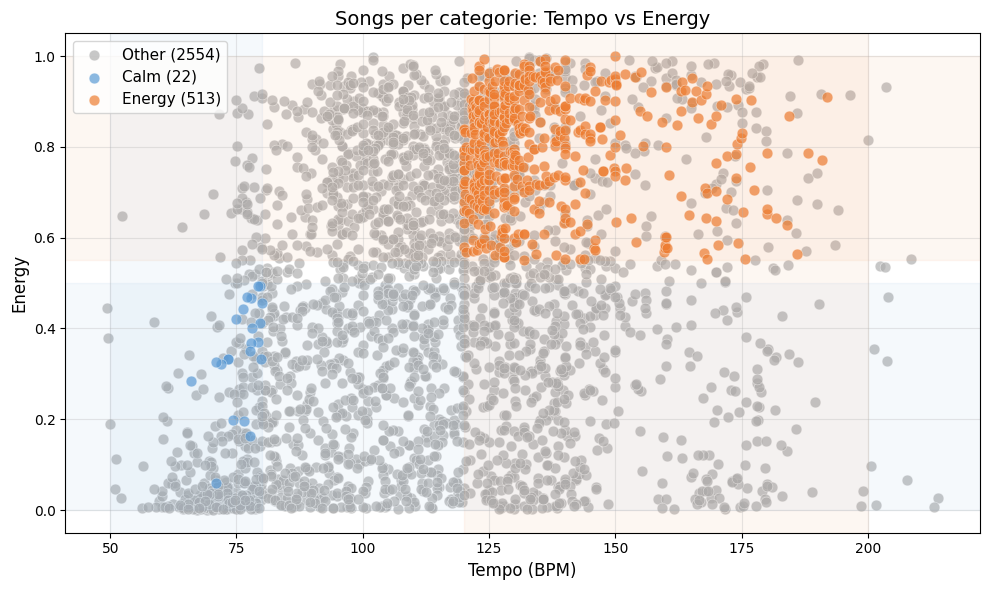

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter_kw = dict(alpha=0.7, edgecolors='white', linewidths=0.4, s=60)

ax.scatter(other_df['tempo'],  other_df['energy'],  color='#b0b0b0', label=f'Other ({len(other_df)})',  **scatter_kw)
ax.scatter(calm_df['tempo'],   calm_df['energy'],   color='#5b9bd5', label=f'Calm ({len(calm_df)})',    **scatter_kw)
ax.scatter(energy_df['tempo'], energy_df['energy'], color='#ed7d31', label=f'Energy ({len(energy_df)})', **scatter_kw)

# Calm zone
ax.axvspan(CALM['tempo_min'], CALM['tempo_max'], alpha=0.06, color='#5b9bd5')
ax.axhspan(0, CALM['energy_max'], alpha=0.06, color='#5b9bd5')

# Energy zone
ax.axvspan(ENERGY['tempo_min'], ENERGY['tempo_max'], alpha=0.06, color='#ed7d31')
ax.axhspan(ENERGY['energy_min'], 1, alpha=0.06, color='#ed7d31')

ax.set_xlabel('Tempo (BPM)', fontsize=12)
ax.set_ylabel('Energy', fontsize=12)
ax.set_title('Songs per categorie: Tempo vs Energy', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Songslijsten bekijken

In [66]:
# Welke kolommen wil je zien?
SHOW_COLS = ['name', 'artists', 'tempo', 'energy', 'acousticness', 'valence', 'loudness', 'danceability']
show_cols = [c for c in SHOW_COLS if c in df.columns]

print("🎵 CALM")
display(calm_df[show_cols].reset_index(drop=True))

🎵 CALM


,name,artists,tempo,energy,acousticness,valence,loudness,danceability
0,Sword from the Stone,Passenger,80.000,0.4560,0.58400,0.429,-9.331,0.627
1,Sleep On The Wing,Bibio,79.899,0.3330,0.80000,0.360,-11.508,0.472
2,Sweetest Thing,Allman Brown,79.733,0.4110,0.70100,0.529,-9.308,0.497
3,Held Down,Laura Marling,79.724,0.4930,0.17900,0.398,-7.884,0.476
4,Maybe I’m Amazed - Remastered 2011,Paul McCartney,79.255,0.4940,0.38700,0.373,-10.407,0.471
5,El Invento,José González,79.184,0.3700,0.94900,0.380,-11.581,0.576
6,Simple Song,Passenger,78.000,0.4020,0.61600,0.598,-11.125,0.631
7,Song From Yesterday,Chance Peña,77.971,0.4670,0.64600,0.499,-9.634,0.472
8,Collecting Dust,Bo Armstrong,77.968,0.3680,0.68000,0.542,-9.123,0.710
9,The Worst Of You,PJ Harding;Noah Cyrus,77.772,0.3500,0.79100,0.404,-10.955,0.555


In [67]:
print("⚡ ENERGY")
display(energy_df[show_cols].reset_index(drop=True))

⚡ ENERGY


,name,artists,tempo,energy,acousticness,valence,loudness,danceability
0,Brokenhearted,Karmin,120.001,0.765,0.007650,0.886,-2.732,0.765
1,Over And Over,Hot Chip,120.002,0.794,0.008240,0.724,-4.446,0.774
2,10:35,Tiësto;Tate McRae,120.003,0.793,0.068300,0.698,-5.733,0.696
3,Gypsy Woman (She's Homeless) (La Da Dee La Da ...,Crystal Waters,120.007,0.779,0.000165,0.453,-10.529,0.645
4,Call Me Maybe,Carly Rae Jepsen,120.021,0.580,0.011400,0.660,-6.548,0.782
...,...,...,...,...,...,...,...,...
508,I'm So Excited,The Pointer Sisters,184.348,0.868,0.096200,0.798,-5.832,0.590
509,Good Thing (with Kehlani),Zedd;Kehlani,185.913,0.564,0.399000,0.574,-3.857,0.693
510,ABC,The Jackson 5,188.119,0.786,0.519000,0.952,-8.469,0.574
511,Changes,Charlie Puth,190.937,0.770,0.077400,0.598,-6.991,0.549


In [68]:
print("🎶 OTHER")
display(other_df[show_cols].reset_index(drop=True))

🎶 OTHER


,name,artists,tempo,energy,acousticness,valence,loudness,danceability
0,Freedom! '90 - Remastered,George Michael,91.703,0.863,0.24300,0.938,-10.352,0.673
1,Lovefool,The Cardigans,111.845,0.636,0.03440,0.890,-6.029,0.704
2,No Diggity,Blackstreet;Dr. Dre;Queen Pen,88.634,0.646,0.30300,0.670,-4.674,0.867
3,Shoop,Salt-N-Pepa,96.918,0.674,0.09100,0.792,-7.232,0.939
4,Praise You (Radio Edit),Fatboy Slim,109.722,0.884,0.04030,0.561,-6.715,0.622
...,...,...,...,...,...,...,...,...
2549,Post Malone (feat. RANI),Sam Feldt;RANI,107.356,0.642,0.07710,0.651,-3.870,0.590
2550,The Business,Tiësto,120.031,0.620,0.41400,0.235,-7.079,0.798
2551,Lose Control,MEDUZA;Becky Hill;Goodboys,123.943,0.527,0.12900,0.530,-8.659,0.598
2552,Fireworks (feat. Moss Kena & The Knocks),Purple Disco Machine;Moss Kena;The Knocks,118.053,0.781,0.00687,0.787,-5.493,0.752


---
## 7. Opslaan als CSV

In [69]:
# ── Output map (pas aan indien nodig) ────────────────────────────────────────
OUTPUT_DIR = Path(f"../../../../data/playlists/{PARTICIPANT}/playlists_output")
# ─────────────────────────────────────────────────────────────────────────────

OUTPUT_DIR.mkdir(exist_ok=True)

calm_df.to_csv(OUTPUT_DIR / f"{PARTICIPANT}_calm.csv",   index=False)
energy_df.to_csv(OUTPUT_DIR / f"{PARTICIPANT}_energy.csv", index=False)
other_df.to_csv(OUTPUT_DIR / f"{PARTICIPANT}_other.csv",  index=False)

print(f"✅ Opgeslagen in '{OUTPUT_DIR}/'")
print(f"   {PARTICIPANT}_calm.csv   → {len(calm_df)} songs")
print(f"   {PARTICIPANT}_energy.csv → {len(energy_df)} songs")
print(f"   {PARTICIPANT}_other.csv  → {len(other_df)} songs")

✅ Opgeslagen in '..\..\..\..\data\playlists\courgette\playlists_output/'
   courgette_calm.csv   → 22 songs
   courgette_energy.csv → 513 songs
   courgette_other.csv  → 2554 songs
